Fraud Detection using machine learning
Step 1 — Load and combine both files

In [1]:
 #pip install pandas scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


In [2]:
# Load both files and combine
df1 = pd.read_csv('Fraudulent_E-Commerce_Transaction_Data.csv')
df2 = pd.read_csv('Fraudulent_E-Commerce_Transaction_Data_2.csv')
df = pd.concat([df1, df2], ignore_index=True)


In [3]:
print(df.shape)        # ~1.5 million rows, 16 columns
print(df.head())
print(df.isnull().sum())  # no nulls — clean dataset

(133709, 16)
                         Transaction ID                           Customer ID  \
0  15d2e414-8735-46fc-9e02-80b472b2580f  d1b87f62-51b2-493b-ad6a-77e0fe13e785   
1  0bfee1a0-6d5e-40da-a446-d04e73b1b177  37de64d5-e901-4a56-9ea0-af0c24c069cf   
2  e588eef4-b754-468e-9d90-d0e0abfc1af0  1bac88d6-4b22-409a-a06b-425119c57225   
3  4de46e52-60c3-49d9-be39-636681009789  2357c76e-9253-4ceb-b44e-ef4b71cb7d4d   
4  074a76de-fe2d-443e-a00c-f044cdb68e21  45071bc5-9588-43ea-8093-023caec8ea1c   

   Transaction Amount     Transaction Date Payment Method Product Category  \
0               58.09  2024-02-20 05:58:41  bank transfer      electronics   
1              389.96  2024-02-25 08:09:45     debit card      electronics   
2              134.19  2024-03-18 03:42:55         PayPal    home & garden   
3              226.17  2024-03-16 20:41:31  bank transfer         clothing   
4              121.53  2024-01-15 05:08:17  bank transfer         clothing   

   Quantity  Customer Age Custo

Good news — no missing values. Now look at the target variable.

In [4]:
print(df['Is Fraudulent'].value_counts())
print(df['Is Fraudulent'].value_counts(normalize=True).round(3))

Is Fraudulent
0    127049
1      6660
Name: count, dtype: int64
Is Fraudulent
0    0.95
1    0.05
Name: proportion, dtype: float64


You will find 95% legitimate, 5% fraud.

Step 2 — Spot the data quality issue

In [5]:
print(df['Customer Age'].describe())
print('Negative ages:', len(df[df['Customer Age'] < 0]))
print('Under 18:', len(df[df['Customer Age'] < 18]))

count    133709.000000
mean         34.486325
std          10.022870
min          -6.000000
25%          28.000000
50%          34.000000
75%          41.000000
max          80.000000
Name: Customer Age, dtype: float64
Negative ages: 25
Under 18: 6006


You will find rows with negative ages. You will also find customers under 18. Both are data quality problems.

So lets remove anyone under 18 and anyone with a negative age in one step. Since minors are not valid account holders.

In [6]:
df = df[df['Customer Age'] >= 18]
print(df.shape)

(127703, 16)


Step 3 — Explore what drives fraud

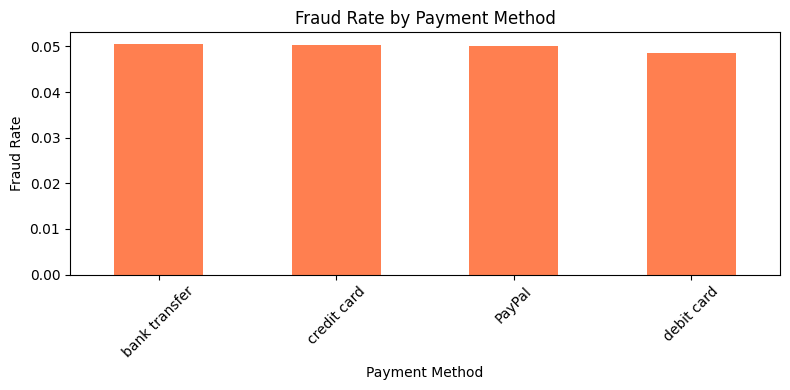

In [7]:
# Fraud rate by payment method
fraud_by_payment = df.groupby('Payment Method')['Is Fraudulent'].mean().sort_values(ascending=False)
fraud_by_payment.plot(kind='bar', color='coral', figsize=(8, 4))
plt.title('Fraud Rate by Payment Method')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

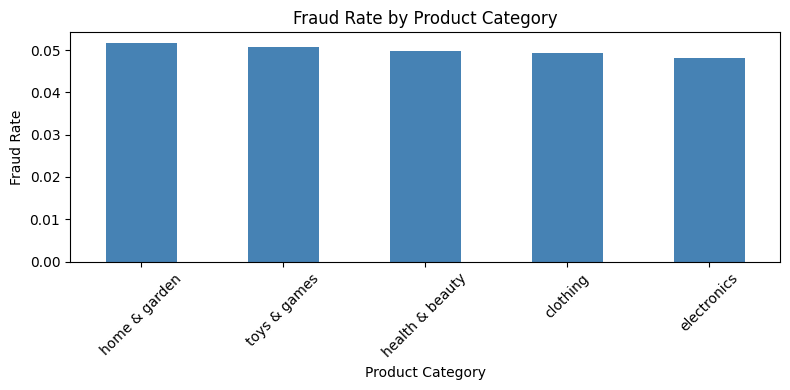

In [8]:
# Fraud rate by product category
fraud_by_category = df.groupby('Product Category')['Is Fraudulent'].mean().sort_values(ascending=False)
fraud_by_category.plot(kind='bar', color='steelblue', figsize=(8, 4))
plt.title('Fraud Rate by Product Category')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


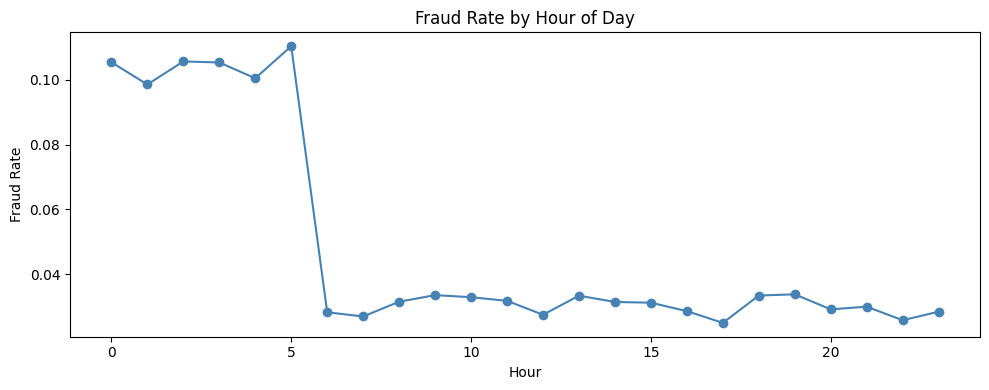

In [9]:
# Fraud rate by hour of day
fraud_by_hour = df.groupby('Transaction Hour')['Is Fraudulent'].mean()
fraud_by_hour.plot(kind='line', color='steelblue', figsize=(10, 4), marker='o')
plt.title('Fraud Rate by Hour of Day')
plt.ylabel('Fraud Rate')
plt.xlabel('Hour')
plt.tight_layout()
plt.show()

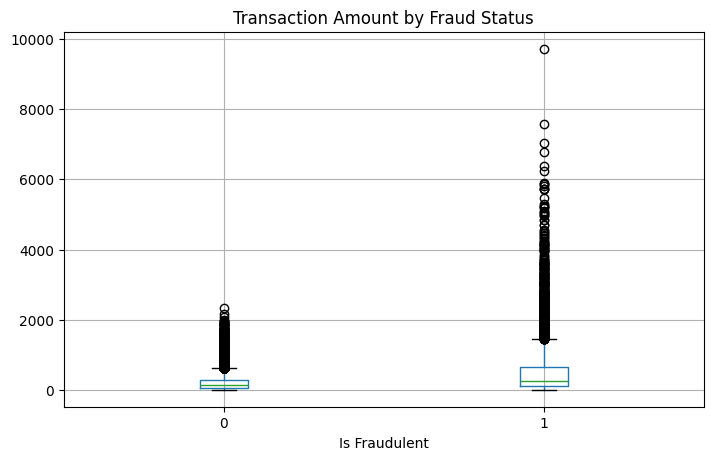

In [10]:
# Transaction amount — fraud vs legitimate
df.boxplot(column='Transaction Amount', by='Is Fraudulent', figsize=(8, 5))
plt.title('Transaction Amount by Fraud Status')
plt.suptitle('')
plt.show()

Look for patterns before modelling. Are fraudulent transactions higher value? Are certain payment methods riskier? Are there peak fraud hours? These are the insights a fraud team would actually use.

Step 4 — Prepare the data

ML models need numbers. Drop identifier columns and encode categorical ones.

In [11]:
# Drop columns not useful for modelling — IDs and addresses
drop_cols = ['Transaction ID', 'Customer ID', 'IP Address',
             'Shipping Address', 'Billing Address', 'Customer Location',
             'Transaction Date']
df = df.drop(columns=drop_cols, errors='ignore')

In [12]:
# One-hot encode categorical columns
df = pd.get_dummies(df, columns=['Payment Method', 'Product Category', 'Device Used'], drop_first=True)

print(df.shape)
print(df.head())

(127703, 15)
   Transaction Amount  Quantity  Customer Age  Is Fraudulent  \
1              389.96         2            40              0   
2              134.19         2            22              0   
3              226.17         5            31              0   
4              121.53         2            51              0   
5              166.41         2            34              0   

   Account Age Days  Transaction Hour  Payment Method_bank transfer  \
1                72                 8                         False   
2                63                 3                         False   
3               124                20                          True   
4               158                 5                          True   
5                38                10                          True   

   Payment Method_credit card  Payment Method_debit card  \
1                       False                       True   
2                       False                      Fals

Step 5 — Train the model

We will use Random Forest with class_weight=’balanced’ to handle the class imbalance.

In [15]:
# Optional: sample for speed during development
#df = df.sample(n=200_000, random_state=42)

X = df.drop('Is Fraudulent', axis=1)
y = df['Is Fraudulent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1        # use all CPU cores to speed things up
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Step 6 — Evaluate properly

              precision    recall  f1-score   support

  Legitimate       0.96      1.00      0.98     24266
       Fraud       0.70      0.12      0.20      1275

    accuracy                           0.95     25541
   macro avg       0.83      0.56      0.59     25541
weighted avg       0.94      0.95      0.94     25541



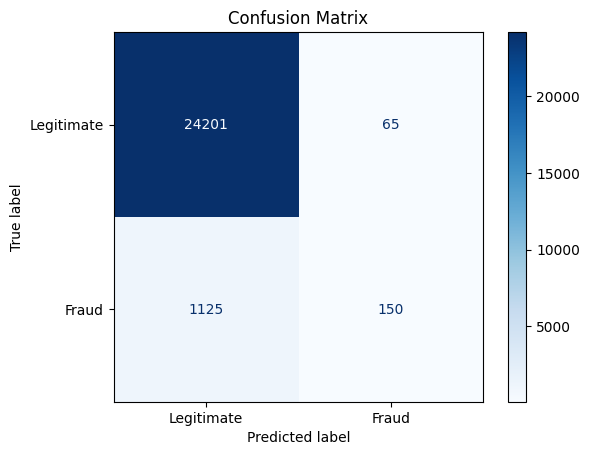

In [16]:
# Classification report
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

Step 7 — Find the most important features

One of the best things about Random Forest is feature importance — it tells you which columns matter most for predicting fraud.

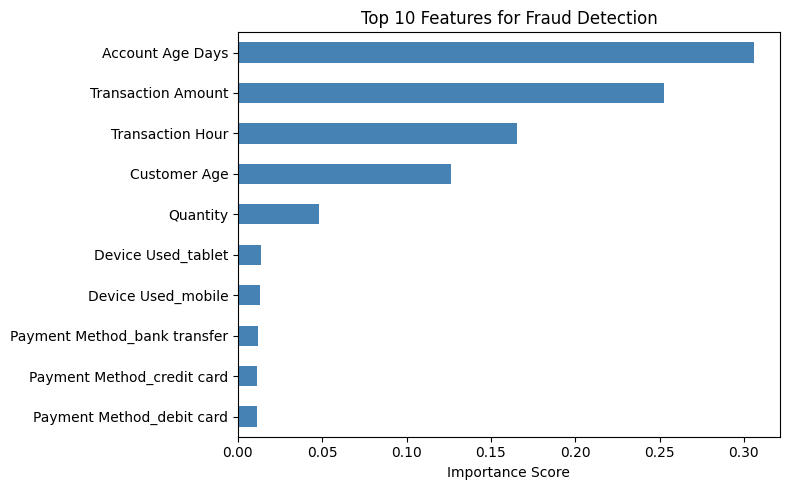

In [17]:
importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

top_features.plot(kind='barh', color='steelblue', figsize=(8, 5))
plt.title('Top 10 Features for Fraud Detection')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()